# Using `mxalign` with a config-file
mxaling can also be used with a config file (typically from the command line).
Here we will show its functionality interactively.

To fully showcase the functionality of `mxalign` we start a dask cluster

In [1]:
from distributed import Client, LocalCluster

In [5]:
cluster = LocalCluster(n_workers=4, threads_per_worker=1)
client = Client(cluster)
client

/users/vanginde/mxalign_dev/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40979 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:40979/status,
Dashboard: http://127.0.0.1:40979/status,Workers: 4
Total threads: 4,Total memory: 64.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41029,Workers: 0
Dashboard: http://127.0.0.1:40979/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36355,Total threads: 1
Dashboard: http://127.0.0.1:44379/status,Memory: 16.00 GiB
Nanny: tcp://127.0.0.1:45705,


2026-03-11 12:15:48,570 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 96411d9a97774f01faad88c5890beccc initialized by task ('concatenate-getitem-open_dataset-original-rechunk-transfer-bf3179aed737f99885395c8bd05c4bb1', 0, 0, 0, 22, 0, 0) executed on worker tcp://127.0.0.1:44183
2026-03-11 12:16:47,528 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 96411d9a97774f01faad88c5890beccc deactivated due to stimulus 'task-finished-1773224207.4140522'
2026-03-11 12:17:48,794 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle efbb4f46ad259661a655bd9dd62bbe79 initialized by task ('concatenate-getitem-open_dataset-original-rechunk-transfer-0b960d8cd144f28946b8421d1111a9ed', 0, 0, 0, 26, 0, 0) executed on worker tcp://127.0.0.1:44183
2026-03-11 12:18:18,363 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 546231d0fc1372419a2bac8b37f390f4 initialized by task ('concatenate-getitem-open_dataset-msl-original-rechunk-transfer-65f65c797a993aeba36c803df733f63b

In [ ]:
from mxalign.runner import Runner

runner = Runner("./config.yaml")

In [8]:
runner.config()

{'datasets': {'la-1024-ea-00': {'loader': 'anemoi-inference',
   'files': ['/scratch/project_465000527/vandenbl/sg-la-comparison/inference-out/la-1024-01-ea-00/2020020100.nc',
    '/scratch/project_465000527/vandenbl/sg-la-comparison/inference-out/la-1024-01-ea-00/2020020200.nc',
    '/scratch/project_465000527/vandenbl/sg-la-comparison/inference-out/la-1024-01-ea-00/2020020300.nc',
    '/scratch/project_465000527/vandenbl/sg-la-comparison/inference-out/la-1024-01-ea-00/2020020400.nc',
    '/scratch/project_465000527/vandenbl/sg-la-comparison/inference-out/la-1024-01-ea-00/2020020500.nc',
    '/scratch/project_465000527/vandenbl/sg-la-comparison/inference-out/la-1024-01-ea-00/2020020600.nc',
    '/scratch/project_465000527/vandenbl/sg-la-comparison/inference-out/la-1024-01-ea-00/2020020700.nc',
    '/scratch/project_465000527/vandenbl/sg-la-comparison/inference-out/la-1024-01-ea-00/2020020800.nc',
    '/scratch/project_465000527/vandenbl/sg-la-comparison/inference-out/la-1024-01-ea-00/

## Load the datasets

In [9]:
runner.load_datasets()

/users/vanginde/mxalign_dev/.venv/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 9.93 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [10]:
runner.datasets

{'la-1024-ea-00': <xarray.Dataset> Size: 14GB
 Dimensions:         (reference_time: 30, lead_time: 25, grid_index: 1142761)
 Coordinates:
   * reference_time  (reference_time) datetime64[ns] 240B 2020-02-01 ... 2020-...
   * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
     latitude        (grid_index) float32 5MB 20.29 20.31 20.32 ... 63.81 63.77
     longitude       (grid_index) float32 5MB -17.49 -17.44 -17.4 ... 74.04 74.11
 Dimensions without coordinates: grid_index
 Data variables:
     2t              (reference_time, lead_time, grid_index) float32 3GB dask.array<chunksize=(1, 25, 1142761), meta=np.ndarray>
     10u             (reference_time, lead_time, grid_index) float32 3GB dask.array<chunksize=(1, 25, 1142761), meta=np.ndarray>
     10v             (reference_time, lead_time, grid_index) float32 3GB dask.array<chunksize=(1, 25, 1142761), meta=np.ndarray>
     msl             (reference_time, lead_time, grid_index) float32 3GB dask.array<chun

## Apply the transformations

In [21]:
runner.transform_datasets()

In [13]:
runner.datasets

{'la-1024-ea-00': <xarray.Dataset> Size: 14GB
 Dimensions:         (reference_time: 30, lead_time: 25, grid_index: 1142761)
 Coordinates:
   * reference_time  (reference_time) datetime64[ns] 240B 2020-02-01 ... 2020-...
   * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
     latitude        (grid_index) float32 5MB 20.29 20.31 20.32 ... 63.81 63.77
     longitude       (grid_index) float32 5MB -17.49 -17.44 -17.4 ... 74.04 74.11
 Dimensions without coordinates: grid_index
 Data variables:
     2t              (reference_time, lead_time, grid_index) float32 3GB dask.array<chunksize=(1, 25, 1142761), meta=np.ndarray>
     10u             (reference_time, lead_time, grid_index) float32 3GB dask.array<chunksize=(1, 25, 1142761), meta=np.ndarray>
     10v             (reference_time, lead_time, grid_index) float32 3GB dask.array<chunksize=(1, 25, 1142761), meta=np.ndarray>
     msl             (reference_time, lead_time, grid_index) float32 3GB dask.array<chun

## Align in space and time

In [14]:
runner.align()

In [16]:
runner.datasets

{'la-1024-ea-00': <xarray.Dataset> Size: 14GB
 Dimensions:         (reference_time: 30, lead_time: 25, grid_index: 1142761)
 Coordinates:
   * reference_time  (reference_time) datetime64[ns] 240B 2020-02-01 ... 2020-...
   * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
     valid_time      (reference_time, lead_time) datetime64[ns] 6kB 2020-02-01...
     latitude        (grid_index) float32 5MB 20.29 20.31 20.32 ... 63.81 63.77
     longitude       (grid_index) float32 5MB -17.49 -17.44 -17.4 ... 74.04 74.11
 Dimensions without coordinates: grid_index
 Data variables:
     2t              (reference_time, lead_time, grid_index) float32 3GB dask.array<chunksize=(1, 25, 1142761), meta=np.ndarray>
     10u             (reference_time, lead_time, grid_index) float32 3GB dask.array<chunksize=(1, 25, 1142761), meta=np.ndarray>
     10v             (reference_time, lead_time, grid_index) float32 3GB dask.array<chunksize=(1, 25, 1142761), meta=np.ndarray>
     m

## Run verification

In [18]:
runner.verify()

/users/vanginde/mxalign_dev/.venv/lib/python3.12/site-packages/properscoring/_crps.py:257: SyntaxWarning: invalid escape sequence '\i'
  CRPS(F, x) = \int_z (F(z) - H(z - x))^2 dz
/users/vanginde/mxalign_dev/.venv/lib/python3.12/site-packages/properscoring/_brier.py:10: SyntaxWarning: invalid escape sequence '\i'
  The Brier score (BS) scores binary forecasts $k \in \{0, 1\}$,
/users/vanginde/mxalign_dev/.venv/lib/python3.12/site-packages/properscoring/_brier.py:102: SyntaxWarning: invalid escape sequence '\i'
  CRPS(F, x) = \int_z BS(F(z), H(z - x)) dz
/users/vanginde/mxalign_dev/.venv/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 64.84 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Saving to myfile.nc


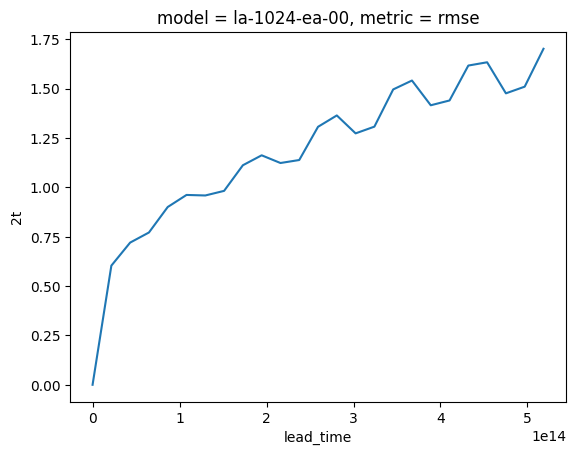

In [ ]:
runner.metrics["2t"].sel(model="la-1024-ea-00", metric="rmse").plot(x="lead_time")

In [23]:
cluster.close()
client.close()

2026-03-11 12:23:45,647 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-03-11 12:23:45,649 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-03-11 12:23:45,723 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-03-11 12:23:45,834 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
